<div style="background:#1565c0;padding:28px 24px;border-radius:8px;margin-bottom:16px;">
<h1 style="color:white;font-size:22px;font-weight:700;margin:0 0 8px;">Agentic AI: From LLMs to Autonomous Agents — A Tutorial</h1>
<p style="color:rgba(255,255,255,0.85);font-size:14px;margin:0;">A structured introduction to Agentic AI — what it is, how it works, and how to build one. No prior AI knowledge required.</p>
</div>

| Section | Topic |
|---------|-------|
| **1** | What is Agentic AI? |
| **2** | The Building Blocks of an Agent |
| **3** | How Agents Think — the ReAct Loop |
| **4** | Tools and Function Calling |
| **5** | Memory and Context |
| **6** | Multi-Agent Systems |
| **7** | Build Your Own Agent |


In [49]:
# !pip install anthropic

In [50]:
import json
import re
from IPython.display import Image, display, HTML
import anthropic
print('Libraries loaded.')

Libraries loaded.


<div style="background:#1565c0;padding:14px 20px;border-radius:6px;margin:24px 0 8px;display:flex;align-items:center;gap:14px;"><span style="background:rgba(255,255,255,0.2);border-radius:50%;width:30px;height:30px;display:inline-flex;align-items:center;justify-content:center;font-weight:700;font-size:14px;color:white;">1</span><span style="font-size:16px;font-weight:600;color:white;">What is Agentic AI?</span></div>


## Section 1 — What is Agentic AI?

You have probably used an AI chatbot — you type a question, it replies. That is a single exchange.
The AI does not plan ahead, does not take actions in the world, and does not remember what you said last week.

**Agentic AI** is different. An AI agent can pursue a goal over multiple steps, decide what to do next,
use tools to gather information or take actions, and adapt its plan based on what it observes.

> **Analogy:** The difference between asking a friend "what is the weather in Paris?" and asking them
> to "plan a three-day trip to Paris next month, book a hotel under £200/night, and send me the itinerary."
> The second task requires planning, tool use, and multiple decisions. That is what an agent does.


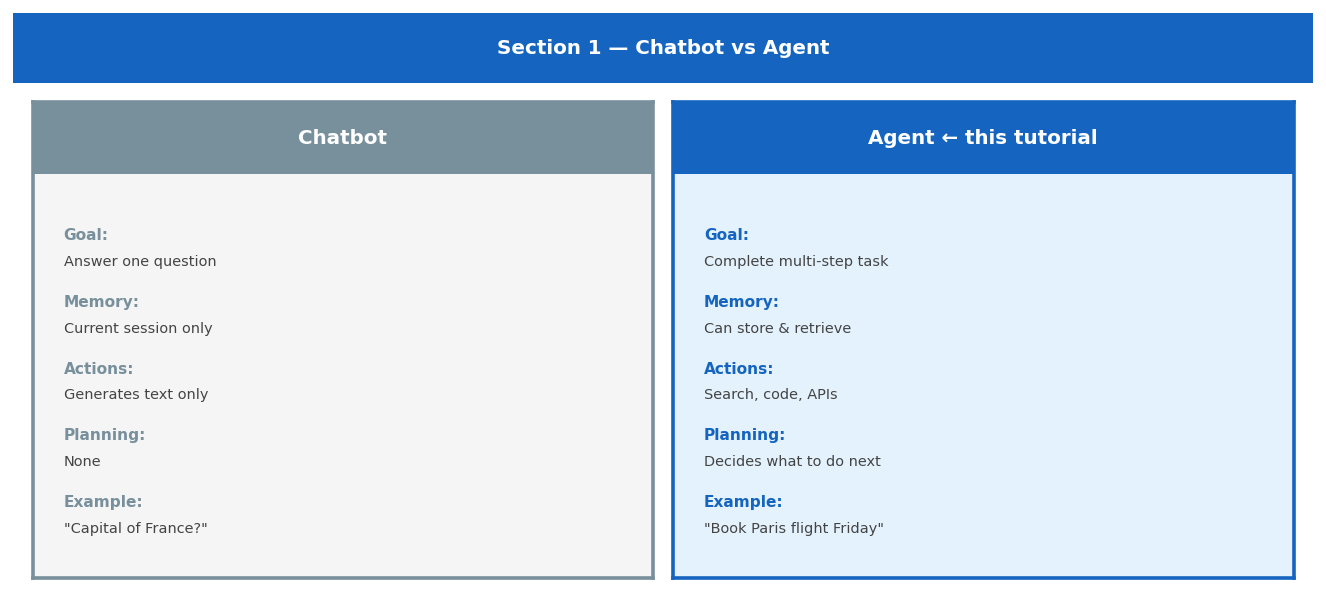

In [11]:
display(Image(filename='./../assets/chatbot_vs_agent.png'))

### Real-world examples of Agentic AI

- **Coding agents** — write code, run it, read the error, fix the bug, repeat
- **Research agents** — search the web, read papers, synthesise a report
- **Customer service agents** — look up orders, process refunds, escalate when needed
- **Data analysis agents** — load a dataset, write analysis code, generate charts
- **Computer use agents** — control a web browser or desktop application directly

### An important clarification — "agent" has two meanings

> **In Reinforcement Learning** (Q-Learning tutorial), an "agent" is a program that takes actions
> in an environment to maximise reward. It has nothing to do with language models.
>
> **In Agentic AI**, an "agent" is a language model that has been given tools and a task, and can act
> autonomously over multiple steps. These are two completely different uses of the same word.
> This tutorial is about the second meaning.


In [12]:
display(HTML('''<div style="background:#f3e5f5;border-left:4px solid #6a1b9a;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#6a1b9a">Key Takeaway:</strong> An <strong>AI agent</strong> is a system that uses a language model as its reasoning engine, combined with tools and memory, to autonomously pursue a goal over multiple steps. Unlike a chatbot, it plans, acts, observes results, and continues until the task is complete.</div>'''))

<div style="background:#2e7d32;padding:14px 20px;border-radius:6px;margin:24px 0 8px;display:flex;align-items:center;gap:14px;"><span style="background:rgba(255,255,255,0.2);border-radius:50%;width:30px;height:30px;display:inline-flex;align-items:center;justify-content:center;font-weight:700;font-size:14px;color:white;">2</span><span style="font-size:16px;font-weight:600;color:white;">The Building Blocks of an Agent</span></div>


## Section 2 — The Building Blocks of an Agent

Every AI agent — regardless of how complex it is — is built from the same four components.


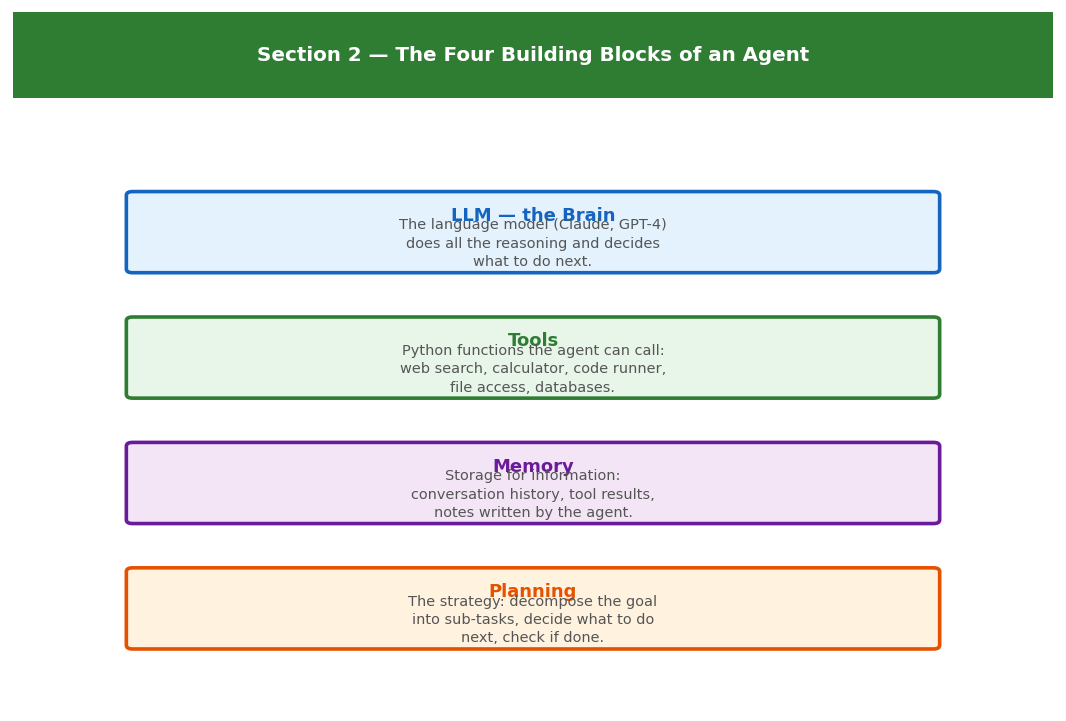

In [14]:
display(Image(filename='./../assets/building_blocks.png'))

In [15]:
# The four building blocks of any AI agent
blocks = [
    ("LLM (Brain)", "The language model — does the reasoning and generates text"),
    ("Tools",       "Functions the agent can call — search, calculator, code runner"),
    ("Memory",      "Storage — conversation history, notes, retrieved facts"),
    ("Planning",    "Strategy for deciding what to do next to achieve the goal"),
]
for name, desc in blocks:
    print(f"{name:<14} → {desc}")


LLM (Brain)    → The language model — does the reasoning and generates text
Tools          → Functions the agent can call — search, calculator, code runner
Memory         → Storage — conversation history, notes, retrieved facts
Planning       → Strategy for deciding what to do next to achieve the goal


In [16]:
display(HTML('''<div style="background:#fff8e1;border-left:4px solid #e65100;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#e65100">Important:</strong> The LLM itself does not browse the internet or run code. It only generates text. The <strong>tools</strong> actually do things in the world. The LLM decides <em>what</em> tool to call and with <em>what</em> arguments — the tool does the work.</div>'''))

In [17]:
display(HTML('''<div style="background:#f3e5f5;border-left:4px solid #6a1b9a;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#6a1b9a">Key Takeaway:</strong> Every agent has four components: an <strong>LLM</strong> (the reasoning engine), <strong>tools</strong> (the ability to act), <strong>memory</strong> (the ability to remember), and <strong>planning</strong> (the strategy). The LLM is the brain — it reads the situation and decides what to do. The tools are the hands — they actually do things in the world.</div>'''))

<div style="background:#6a1b9a;padding:14px 20px;border-radius:6px;margin:24px 0 8px;display:flex;align-items:center;gap:14px;"><span style="background:rgba(255,255,255,0.2);border-radius:50%;width:30px;height:30px;display:inline-flex;align-items:center;justify-content:center;font-weight:700;font-size:14px;color:white;">3</span><span style="font-size:16px;font-weight:600;color:white;">How Agents Think — the ReAct Loop</span></div>


## Section 3 — How Agents Think — the ReAct Loop

The most common pattern for how an agent works is called **ReAct** — short for *Reason + Act*.
At each step the agent does three things:

1. **Thought** — reason: "What do I know? What do I still need? What should I do next?"
2. **Action** — call a tool with specific inputs
3. **Observation** — read the tool's output and add it to context

This cycle repeats until the agent decides the task is complete.


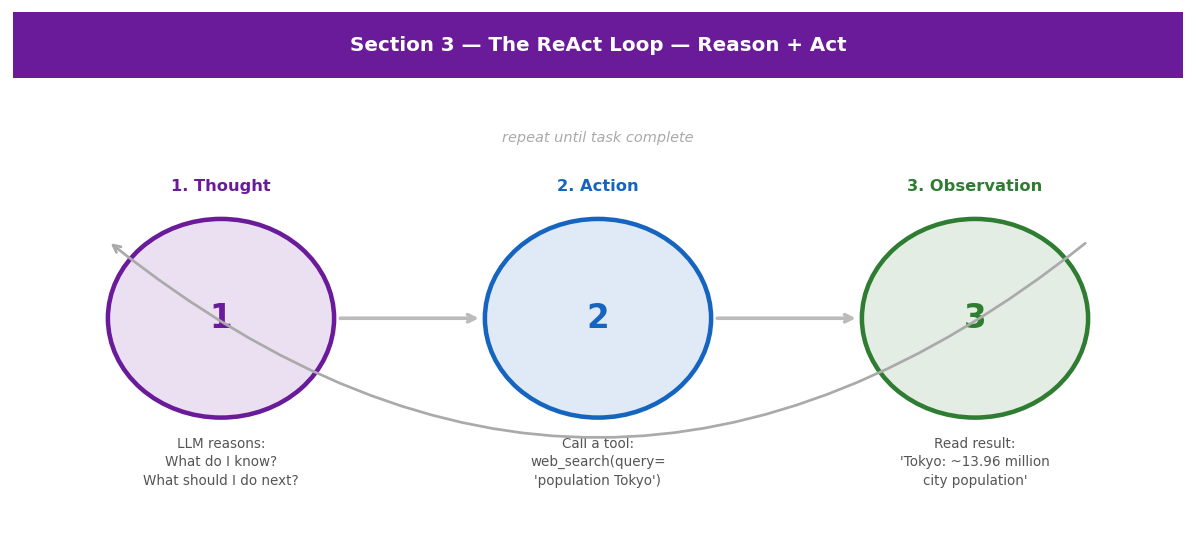

In [19]:
display(Image(filename='./../assets/react_loop.png'))

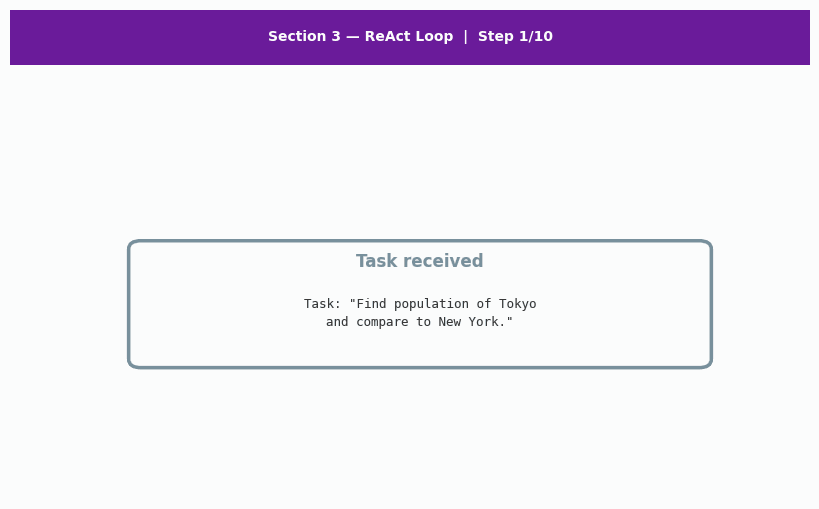

In [21]:
display(Image(filename='./../assets/react_trace.gif'))

In [22]:
# The ReAct loop — pseudocode (illustrative only)
if False:
    while not finished:
        thought = llm.think(task, history, tools)       # Reason
        if thought.is_final_answer:
            print(thought.answer)
            finished = True
        else:
            result  = tools[thought.tool_name].call(thought.tool_input)  # Act
            history.append({"tool": thought.tool_name, "result": result}) # Observe


In [23]:
display(HTML('''<div style="background:#f3e5f5;border-left:4px solid #6a1b9a;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#6a1b9a">Key Takeaway:</strong> The <strong>ReAct loop</strong> — Thought → Action → Observation — is the core pattern of how agents work. The LLM reasons about what to do, calls a tool, reads the result, and repeats until the task is complete.</div>'''))

<div style="background:#e65100;padding:14px 20px;border-radius:6px;margin:24px 0 8px;display:flex;align-items:center;gap:14px;"><span style="background:rgba(255,255,255,0.2);border-radius:50%;width:30px;height:30px;display:inline-flex;align-items:center;justify-content:center;font-weight:700;font-size:14px;color:white;">4</span><span style="font-size:16px;font-weight:600;color:white;">Tools and Function Calling</span></div>


## Section 4 — Tools and Function Calling

Tools are what turn a language model from a text generator into something that can actually do things.
A tool is simply a **Python function** that the agent is allowed to call.

**Key concept — function calling:** Modern LLMs can output structured JSON specifying which function
to call and with what arguments. Your code executes that function and sends the result back to the model.


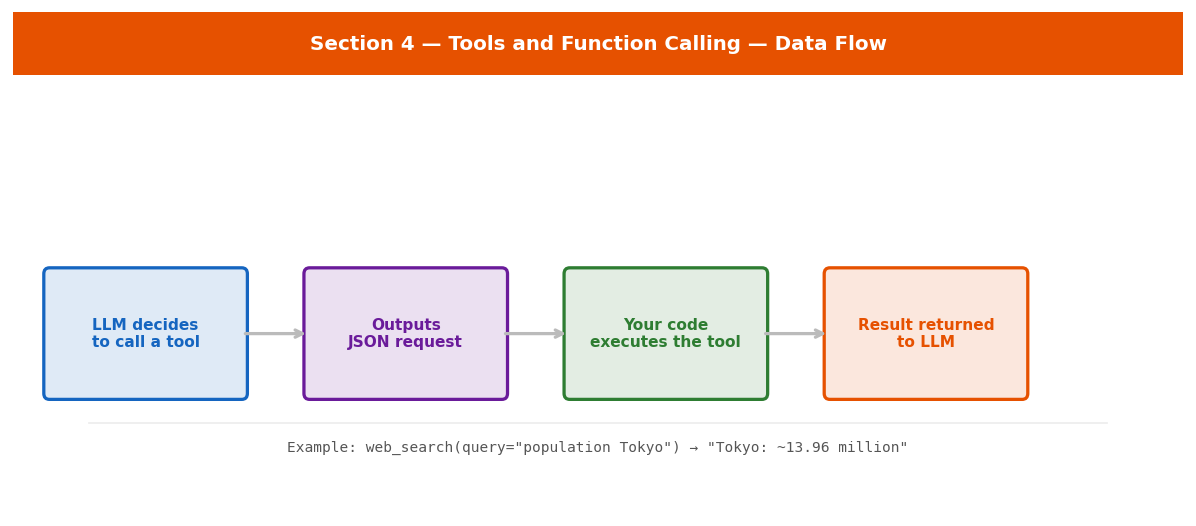

In [25]:
display(Image(filename='./../assets/tool_calling.png'))

In [26]:
# A tool has two parts: the Python function + the JSON schema

def web_search(query: str) -> str:
    """Search the web and return results."""
    return f"Results for '{query}': ..."

web_search_schema = {
    "name":        "web_search",
    "description": "Search the internet for current information on any topic.",
    "input_schema": {
        "type": "object",
        "properties": {
            "query": {"type": "string", "description": "The search query"}
        },
        "required": ["query"]
    }
}
print("Tool: ", web_search_schema["name"])
print("Desc: ", web_search_schema["description"])

# Common tools
tools = [
    ("web_search",    "Search the internet for current information"),
    ("run_python",    "Execute Python code and return the output"),
    ("calculator",    "Evaluate a mathematical expression"),
    ("read_file",     "Read the contents of a file"),
    ("send_email",    "Send an email to a specified address"),
    ("get_weather",   "Retrieve current weather for a location"),
]
print()
for name, desc in tools:
    print(f"  {name:<20} {desc}")


Tool:  web_search
Desc:  Search the internet for current information on any topic.

  web_search           Search the internet for current information
  run_python           Execute Python code and return the output
  calculator           Evaluate a mathematical expression
  read_file            Read the contents of a file
  send_email           Send an email to a specified address
  get_weather          Retrieve current weather for a location


In [27]:
display(HTML('''<div style="background:#f3e5f5;border-left:4px solid #6a1b9a;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#6a1b9a">Key Takeaway:</strong> <strong>Tools</strong> are Python functions agents can call. Each tool has a schema describing what it does and what inputs it needs. The LLM outputs a structured call request; your code executes it and returns the result. The LLM reads that result and decides the next step.</div>'''))

<div style="background:#00796b;padding:14px 20px;border-radius:6px;margin:24px 0 8px;display:flex;align-items:center;gap:14px;"><span style="background:rgba(255,255,255,0.2);border-radius:50%;width:30px;height:30px;display:inline-flex;align-items:center;justify-content:center;font-weight:700;font-size:14px;color:white;">5</span><span style="font-size:16px;font-weight:600;color:white;">Memory and Context</span></div>


## Section 5 — Memory and Context

A raw LLM has no persistent memory. An agent needs to remember things — what it has already tried,
what facts it has retrieved, what the user said earlier.

There are four types of memory an agent can use:


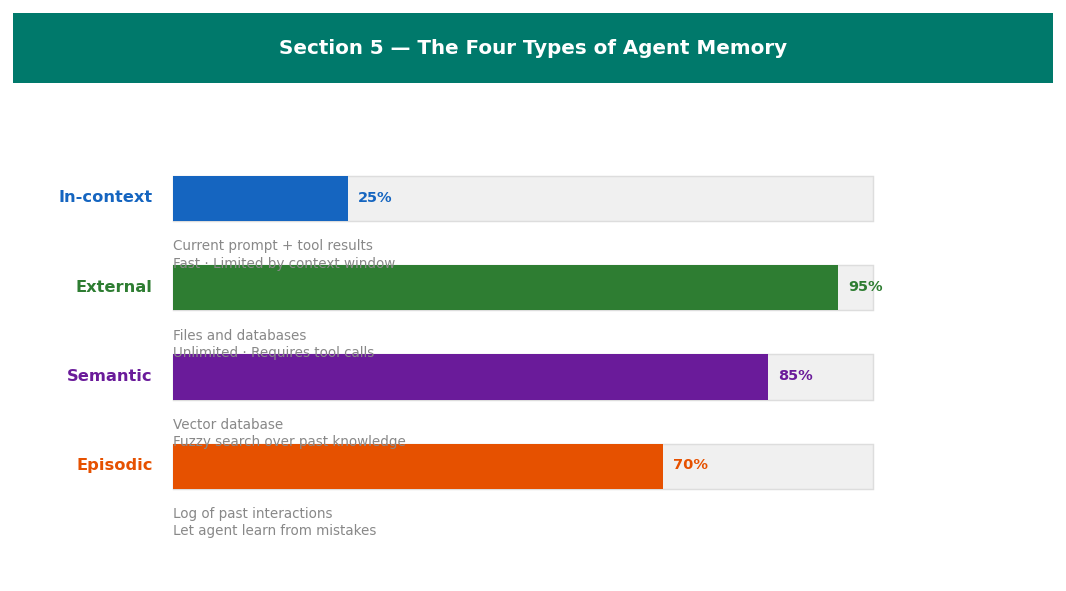

In [29]:
display(Image(filename='./../assets/memory_types.png'))

In [30]:
class AgentMemory:
    """Stores the agent's context window contents."""
    def __init__(self): self.messages = []

    def add_user_message(self, text):
        self.messages.append({"role": "user", "content": text})

    def add_tool_result(self, tool_name, result):
        self.messages.append({"role": "tool", "name": tool_name, "content": result})

    def add_assistant_message(self, text):
        self.messages.append({"role": "assistant", "content": text})

    def token_count(self):
        return sum(len(str(m)) for m in self.messages) // 4

mem = AgentMemory()
mem.add_user_message("Find the population of Tokyo.")
mem.add_tool_result("web_search", "Tokyo population: ~13.96 million")
mem.add_assistant_message("Tokyo's population is approximately 13.96 million.")
print(f"Messages in memory: {len(mem.messages)}")
print(f"Estimated tokens:   {mem.token_count()}")


Messages in memory: 3
Estimated tokens:   57


In [31]:
display(HTML('''<div style="background:#f3e5f5;border-left:4px solid #6a1b9a;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#6a1b9a">Key Takeaway:</strong> Agents use four types of memory: <strong>in-context</strong> (the current prompt — fast but limited), <strong>external</strong> (files and databases — unlimited but requires tool calls), <strong>semantic</strong> (vector search over past knowledge), and <strong>episodic</strong> (a log of past interactions). Managing memory well is one of the hardest parts of building a reliable agent.</div>'''))

<div style="background:#ad1457;padding:14px 20px;border-radius:6px;margin:24px 0 8px;display:flex;align-items:center;gap:14px;"><span style="background:rgba(255,255,255,0.2);border-radius:50%;width:30px;height:30px;display:inline-flex;align-items:center;justify-content:center;font-weight:700;font-size:14px;color:white;">6</span><span style="font-size:16px;font-weight:600;color:white;">Multi-Agent Systems</span></div>


## Section 6 — Multi-Agent Systems

A single agent works well for focused tasks. But some problems are too large for one agent.
The solution is **multi-agent systems** — multiple agents working together.


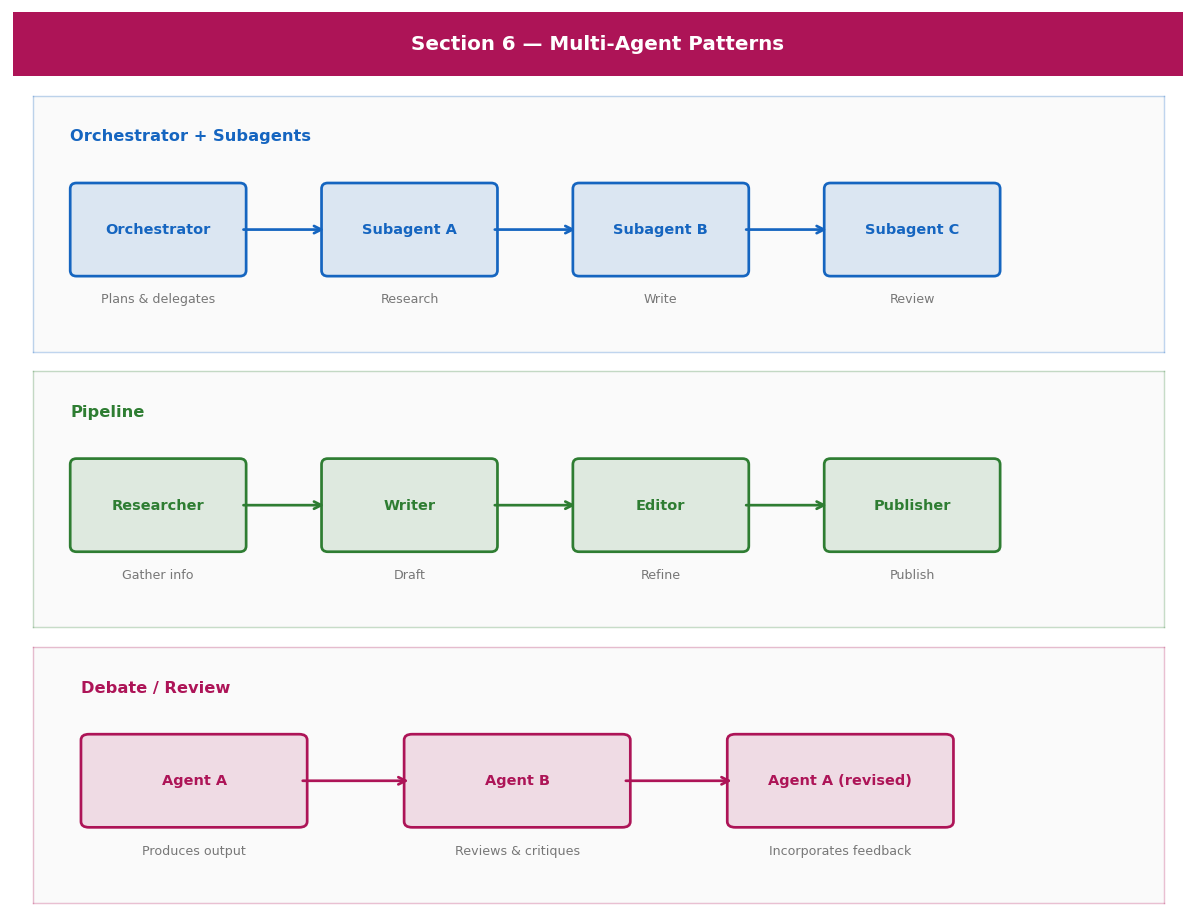

In [42]:
display(Image(filename='./../assets/multi_agent.png'))

In [43]:
# Multi-agent patterns
patterns = [
    ("Orchestrator + Subagents",
     "One orchestrator plans and delegates. Subagents execute.",
     "Large complex tasks with parallel workstreams"),
    ("Pipeline",
     "Agent 1 output feeds Agent 2 input, and so on.",
     "Sequential: Researcher → Writer → Editor → Publisher"),
    ("Debate / Review",
     "Agents propose, critique, and improve each other's outputs.",
     "Tasks where accuracy and quality are critical"),
]
for name, desc, use in patterns:
    print(f"Pattern:  {name}\n  {desc}\n  Use case: {use}\n")


Pattern:  Orchestrator + Subagents
  One orchestrator plans and delegates. Subagents execute.
  Use case: Large complex tasks with parallel workstreams

Pattern:  Pipeline
  Agent 1 output feeds Agent 2 input, and so on.
  Use case: Sequential: Researcher → Writer → Editor → Publisher

Pattern:  Debate / Review
  Agents propose, critique, and improve each other's outputs.
  Use case: Tasks where accuracy and quality are critical



In [44]:
display(HTML('''<div style="background:#f3e5f5;border-left:4px solid #6a1b9a;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#6a1b9a">Key Takeaway:</strong> <strong>Multi-agent systems</strong> split complex tasks across specialised agents. The most common pattern is an orchestrator that plans and delegates, and subagents that execute. Other patterns include pipelines and debate/review for quality control.</div>'''))

<div style="background:#37474f;padding:14px 20px;border-radius:6px;margin:24px 0 8px;display:flex;align-items:center;gap:14px;"><span style="background:rgba(255,255,255,0.2);border-radius:50%;width:30px;height:30px;display:inline-flex;align-items:center;justify-content:center;font-weight:700;font-size:14px;color:white;">7</span><span style="font-size:16px;font-weight:600;color:white;">Build Your Own Agent</span></div>


## Section 7 — Build Your Own Agent

Complete, runnable agent using the **Anthropic API** (Claude).
Implements the full ReAct loop with a calculator and web search tool.

```
pip install anthropic
```


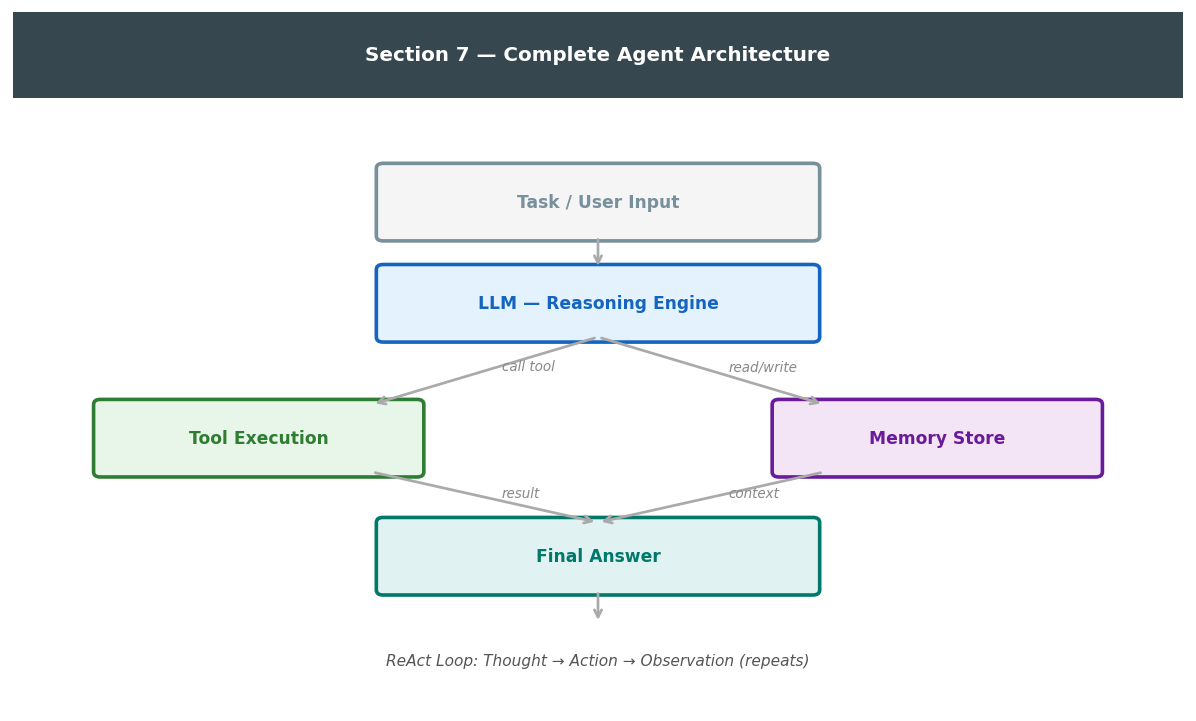

In [45]:
display(Image(filename='./../assets/agent_architecture.png'))

In [51]:
import anthropic, json, math

# ─── 1. TOOLS ────────────────────────────────────────────────────
def calculator(expression: str) -> str:
    try:
        return str(eval(expression, {"__builtins__": {}}, vars(math)))
    except Exception as e:
        return f"Error: {e}"

def web_search(query: str) -> str:
    mock = {
        "population tokyo":   "Tokyo: ~13.96 million city, ~37.4 million metro.",
        "population new york": "New York City: ~8.3 million.",
    }
    for k, v in mock.items():
        if k in query.lower(): return v
    return f"No results for: {query}"

TOOLS = [
    {"name": "calculator", "description": "Evaluate a math expression.",
     "input_schema": {"type":"object","properties":{"expression":{"type":"string"}},"required":["expression"]}},
    {"name": "web_search",  "description": "Search the web for current information.",
     "input_schema": {"type":"object","properties":{"query":{"type":"string"}},"required":["query"]}},
]
TOOL_FNS = {"calculator": calculator, "web_search": web_search}

# ─── 2. AGENT LOOP ───────────────────────────────────────────────
def run_agent(task: str, api_key: str):
    client   = anthropic.Anthropic(api_key=api_key)
    messages = [{"role": "user", "content": task}]
    while True:
        response = client.messages.create(
            model="claude-opus-4-5", max_tokens=1024,
            tools=TOOLS, messages=messages
        )
        messages.append({"role": "assistant", "content": response.content})
        if response.stop_reason == "end_turn":
            return next(b.text for b in response.content if hasattr(b, "text"))
        tool_results = []
        for block in response.content:
            if block.type == "tool_use":
                result = TOOL_FNS[block.name](**block.input)
                print(f"Tool: {block.name}({block.input}) → {result}")
                tool_results.append({"type":"tool_result","tool_use_id":block.id,"content":result})
        messages.append({"role": "user", "content": tool_results})

# result = run_agent("What is the population of Tokyo? How many times larger than New York?",
#                    api_key="your-api-key-here")
print("Agent ready. Set your API key and call run_agent().")


Agent ready. Set your API key and call run_agent().


---
## Summary

| Concept | What it does |
|---------|-------------|
| **LLM** | The reasoning engine — decides what to do at each step |
| **Tools** | Python functions the LLM can call to interact with the world |
| **Memory** | Context window plus optional external storage |
| **ReAct loop** | Thought → Action → Observation, repeated until done |
| **Multi-agent** | Multiple specialised agents for complex tasks |

Agents = LLM + Tools + Memory + ReAct loop. Everything else builds on these four components.

---
*Tutorial produced as part of the ABRHS Research Club workshop series.*
